# The FLARE pipeline: classification, uncertainty, and finding the unexpected

### ZTF Summer School — using a production classifier, end to end

This notebook uses the **pretrained FLARE model** exactly as a survey broker
would: load the shipped weights, classify, get calibrated probabilities and
conformal prediction sets — then turn the same machinery into an **anomaly
detector** with the LUNA package, and watch nine labelled examples transform
it (active learning).

No training required anywhere; everything runs on CPU.

In [1]:
import os, sys, warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, "../..")
from flare import FlareClassifier, BROAD_CLASSES
from flare import data as D
from flare.taxonomy import ID2BROAD_ID

DATA_DIR = os.environ.get("FLARE_DATA",
    "/work/hdd/bcrv/ffontinelenunes/data/AppleCider/photo_events")
D.DATA_DIR = __import__("pathlib").Path(DATA_DIR)

CLASS_COLOR = {"SNI": "#0072B2", "SNII": "#E69F00", "CV": "#009E73",
               "AGN": "#CC79A7", "TDE": "#D55E00"}
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
print("Setup OK")

Setup OK


## 1. Classification with the pretrained model

One call loads the bundled weights and the conformal calibration.

In [2]:
clf5 = FlareClassifier.from_pretrained()

manifest = D.load_manifest("test")
kept, _ = D.filter_manifest_quality(manifest)
y_true = np.array([ID2BROAD_ID[int(l)] for l in kept.label])

X_test_raw = clf5.features_from_files(kept.filepath.tolist())   # ~1 min
P5 = clf5.predict_proba(X_test_raw)
pred5 = P5.argmax(1)
print(f"{len(y_true)} test objects classified")

E20260729 00:22:56.438985 262807 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.
E20260729 00:22:56.485373 262807 polynomial.cc:235] Failed to extract eigenvalues from companion matrix.
W20260729 00:22:56.485400 262807 polynomial.cc:305] Unable to find the critical points of the interpolating polynomial.
E20260729 00:22:56.485493 262807 polynomial.cc:235] Failed to extract eigenvalues from companion matrix.
W20260729 00:22:56.485503 262807 polynomial.cc:305] Unable to find the critical points of the interpolating polynomial.
E20260729 00:22:56.576911 262807 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.


E20260729 00:22:56.792412 262807 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.
E20260729 00:22:56.863827 262807 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.


E20260729 00:22:57.208509 262807 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.
E20260729 00:22:57.260006 262807 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.


E20260729 00:22:57.704669 262807 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.


E20260729 00:22:57.969631 262807 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.
E20260729 00:22:57.970059 262807 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.


E20260729 00:22:58.411814 262807 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.


E20260729 00:22:58.924341 262807 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.
E20260729 00:22:59.040313 262807 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.
E20260729 00:22:59.113456 262807 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.


E20260729 00:22:59.202409 262807 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.
E20260729 00:22:59.231338 262807 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.
E20260729 00:22:59.345678 262807 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.


1979 test objects classified


E20260729 00:22:59.804247 262807 program_evaluator.h:286] Accumulated cost = inf is not a finite number. Evaluation failed.


In [3]:
from sklearn.metrics import (classification_report, balanced_accuracy_score,
                             f1_score, average_precision_score)

auprc = np.mean([average_precision_score((y_true == c).astype(int), P5[:, c])
                 for c in range(5)])
print(f"accuracy {(pred5 == y_true).mean():.4f} | balanced "
      f"{balanced_accuracy_score(y_true, pred5):.4f} | macro F1 "
      f"{f1_score(y_true, pred5, average='macro'):.4f} | macro AUPRC {auprc:.4f}\n")
print(classification_report(y_true, pred5, target_names=BROAD_CLASSES, digits=3))

accuracy 0.9565 | balanced 0.8083 | macro F1 0.8406 | macro AUPRC 0.9140

              precision    recall  f1-score   support

         SNI      0.963     0.974     0.969       886
        SNII      0.898     0.840     0.868       219
          CV      0.865     0.912     0.888        91
         AGN      0.976     0.982     0.979       774
         TDE      1.000     0.333     0.500         9

    accuracy                          0.957      1979
   macro avg      0.940     0.808     0.841      1979
weighted avg      0.956     0.957     0.956      1979



## 2. Not just a label — a *set* you can trust

For hard objects a single label is a guess. FLARE's conformal layer returns a
**prediction set** — possibly two or three classes — with a coverage
guarantee: the true class is inside at least 90% of the time, per class.

In [4]:
set_names = clf5.prediction_sets(X_test_raw)     # list of class-name lists
sets = np.array([[c in s for c in BROAD_CLASSES] for s in set_names])
sizes = sets.sum(1)
print(f"average set size: {sizes.mean():.2f}   "
      f"(singletons: {(sizes == 1).mean():.0%}, pairs or more: {(sizes >= 2).mean():.0%})\n")
print("per-class coverage (target 0.90):")
for c, name in enumerate(BROAD_CLASSES):
    m = y_true == c
    print(f"  {name:5s} (n={m.sum():4d}): {sets[m, c].mean():.2f}")

# hard objects: sets larger than one (multiple candidates) or EMPTY —
# an empty set is the model abstaining: "at this confidence, none of my
# classes fits", which is itself a useful alert for a human to inspect.
hard = np.where(sizes != 1)[0][:8]
for i in hard:
    inset = [BROAD_CLASSES[c] for c in range(5) if sets[i, c]]
    print(f"  {kept.obj_id.iloc[i]}: true={BROAD_CLASSES[y_true[i]]:5s} "
          f"set={inset if inset else '[] (abstains)'}")

average set size: 0.96   (singletons: 95%, pairs or more: 0%)

per-class coverage (target 0.90):
  SNI   (n= 886): 0.91
  SNII  (n= 219): 0.92
  CV    (n=  91): 0.87
  AGN   (n= 774): 0.91
  TDE   (n=   9): 0.67
  ZTF19aakirwj: true=SNI   set=[] (abstains)
  ZTF18abuqaby: true=AGN   set=[] (abstains)
  ZTF18acnokkc: true=AGN   set=[] (abstains)
  ZTF18aceokyk: true=AGN   set=[] (abstains)
  ZTF19aaloayl: true=AGN   set=[] (abstains)
  ZTF18acbvgtu: true=SNI   set=[] (abstains)
  ZTF18aaripcr: true=SNI   set=[] (abstains)
  ZTF24aakfgvg: true=SNI   set=[] (abstains)


## 3. The classifier that has never seen a TDE

Now the anomaly experiment. We load a variant of FLARE trained with **every
TDE removed** — four classes only. To this model, tidal disruption events do
not exist. What does it do when it meets one?

In [5]:
KNOWN = ["SNI", "SNII", "CV", "AGN"]
clf4 = FlareClassifier.from_pretrained(
    model_path="../../models/flare_lgbm_no_tde.txt",
    conformal_path="/nonexistent")               # no conformal for this one

is_tde = y_true == BROAD_CLASSES.index("TDE")
P4 = clf4.predict_proba(X_test_raw)              # (N, 4) — TDE is not an option

tab = pd.DataFrame(P4[is_tde], columns=KNOWN,
                   index=kept.obj_id[is_tde]).round(2)
tab["prediction"] = [KNOWN[i] for i in P4[is_tde].argmax(1)]
print(tab.to_string())
print(f"\nmean confidence on the {is_tde.sum()} TDEs : {P4[is_tde].max(1).mean():.2f}")
print(f"mean confidence on everything else: {P4[~is_tde].max(1).mean():.2f}")

               SNI  SNII    CV   AGN prediction
obj_id                                         
ZTF21abcgnqn  0.32  0.20  0.03  0.45        AGN
ZTF24aazlori  0.01  0.01  0.00  0.98        AGN
ZTF21abhrchb  0.59  0.30  0.00  0.11        SNI
ZTF21abowtqx  0.00  0.01  0.00  0.99        AGN
ZTF18acaqdaa  0.05  0.08  0.10  0.77        AGN
ZTF22aaaedas  0.22  0.13  0.08  0.58        AGN
ZTF20abgbdpr  0.04  0.21  0.03  0.72        AGN
ZTF20abowque  0.03  0.11  0.01  0.86        AGN
ZTF19aatylnl  0.06  0.54  0.07  0.33       SNII

mean confidence on the 9 TDEs : 0.72
mean confidence on everything else: 0.96


The model cannot name what it has never seen — but it is measurably **less
confident**. That drop in confidence is a signal, and LUNA turns signals like
it into a systematic detector.

## 4. LUNA: many ways to be surprised

LUNA fits an ensemble of anomaly scorers on the "normal" world (the four known
classes) and scores a **discovery pool**: the full test set plus the 47
training TDEs we excluded — 56 hidden TDEs in ~2,000 objects. Nothing in the
pool ever touched the model or the scorers.

In [6]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from luna.pipeline import LUNAPipeline

tr = pd.read_parquet("../../artifacts/features_train_h100.parquet")
ytr = tr["label"].map(lambda x: ID2BROAD_ID[int(x)]).values
Xtr_raw = tr.drop(columns=["obj_id", "label"])
no_tde = ytr != BROAD_CLASSES.index("TDE")
Xtr_raw, ytr4 = Xtr_raw[no_tde], ytr[no_tde]

imputer = SimpleImputer(strategy="median").fit(Xtr_raw)
scaler  = RobustScaler().fit(imputer.transform(Xtr_raw))
embed = lambda Xdf: np.clip(scaler.transform(imputer.transform(Xdf)), -10, 10)
logits = lambda Xdf: clf4.booster.predict(Xdf, raw_score=True)

train_data = {"embeddings": embed(Xtr_raw), "labels": ytr4, "logits": logits(Xtr_raw)}

tde_tr = tr[~no_tde].reset_index(drop=True)          # the 47 excluded train TDEs
X_query_raw = pd.concat([X_test_raw.reset_index(drop=True),
                         tde_tr.drop(columns=["obj_id", "label"])],
                        ignore_index=True)[X_test_raw.columns]
train_fp = D.load_manifest("train").set_index("obj_id").filepath
query_ids = np.concatenate([kept.obj_id.values, tde_tr.obj_id.values])
query_fp  = np.concatenate([kept.filepath.values, train_fp.loc[tde_tr.obj_id].values])
truth_q   = np.concatenate([[BROAD_CLASSES[i] for i in y_true], ["TDE"] * len(tde_tr)])
is_tde_q  = truth_q == "TDE"

query_data = {"embeddings": embed(X_query_raw), "logits": logits(X_query_raw)}
print(f"LUNA train: {train_data['embeddings'].shape}  |  pool: "
      f"{query_data['embeddings'].shape[0]} objects, {is_tde_q.sum()} hidden TDEs")

LUNA train: (9170, 160)  |  pool: 2026 objects, 56 hidden TDEs


In [7]:
pipe = LUNAPipeline(target_far=0.01)
pipe.fit(train_data)
scores = pipe.score(query_data)
print("scorers:", list(scores))

  [LUNA] fit msp in 0.0s


  [LUNA] fit entropy in 0.0s


  [LUNA] fit energy in 0.0s


  [LUNA] fit odin in 0.0s


  [LUNA] fit mahal_global in 0.0s


...

  [LUNA] fit lof in 0.1s


  [LUNA] fit pca_recon in 0.0s


  [LUNA] fit mrs in 0.1s


  [LUNA] Fitted 14 scorers: ['msp', 'entropy', 'energy', 'odin', 'mahal_global', 'mahal_class', 'mahal_within', 'knn', 'typicality', 'gmm', 'iforest', 'lof', 'pca_recon', 'mrs']


scorers: ['msp', 'entropy', 'energy', 'odin', 'mahal_global', 'mahal_class', 'mahal_within', 'knn', 'typicality', 'gmm', 'iforest', 'lof', 'pca_recon', 'mrs']


## 5. Stage 1 — blind discovery

No anomaly labels at all: just average the ranks across all scorers and look
at the top of the list.

In [8]:
from scipy.stats import rankdata
from sklearn.metrics import roc_auc_score

R = np.mean([rankdata(scores[k]) for k in scores], axis=0)
order = np.argsort(R)[::-1]

topk = 40
print(f"top-{topk} blind anomalies contain "
      f"{is_tde_q[order[:topk]].sum()}/{is_tde_q.sum()} hidden TDEs "
      f"(chance: {topk * is_tde_q.mean():.1f})")
print(f"blind consensus AUC: {roc_auc_score(is_tde_q, R):.3f}")

top-40 blind anomalies contain 6/56 hidden TDEs (chance: 1.1)
blind consensus AUC: 0.718


## 6. Stage 2 — active learning: nine labels change everything

In a real survey you eventually confirm a few anomalies spectroscopically.
Feed those back: LUNA's supervised combiner learns how to *weight* the scorers
using the 9 validation TDEs (and only those — the pool stays untouched).

In [9]:
va = pd.read_parquet("../../artifacts/features_val_h100.parquet")
yva = va["label"].map(lambda x: ID2BROAD_ID[int(x)]).values
Xva_raw = va.drop(columns=["obj_id", "label"])
va_tde = yva == BROAD_CLASSES.index("TDE")

id_data  = {"embeddings": embed(Xva_raw[~va_tde]), "logits": logits(Xva_raw[~va_tde])}
ood_data = {"embeddings": embed(Xva_raw[va_tde]),  "logits": logits(Xva_raw[va_tde])}
print(f"combiner training: {(~va_tde).sum()} normal + {va_tde.sum()} confirmed TDEs")

pipe.fit_combiner(id_data, ood_data, verbose=False)
out = pipe.predict(query_data)
es = out["ensemble_score"]

print(f"\nsupervised AUC : {roc_auc_score(is_tde_q, es):.3f}"
      f"   (blind was {roc_auc_score(is_tde_q, R):.3f})")
flag = out["flagged"]
print(f"flagged at 1% FAR: {flag.sum()} objects, containing "
      f"{is_tde_q[flag].sum()}/{is_tde_q.sum()} hidden TDEs")

combiner training: 1982 normal + 9 confirmed TDEs



supervised AUC : 0.905   (blind was 0.718)
flagged at 1% FAR: 49 objects, containing 20/56 hidden TDEs


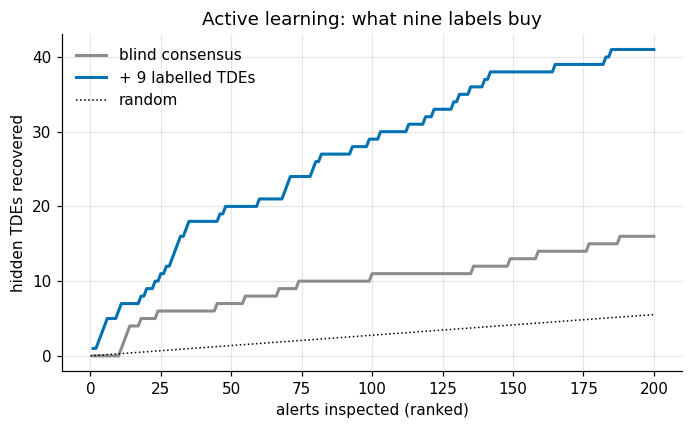

In [10]:
# the discovery curve: TDEs found vs alerts inspected
fig, ax = plt.subplots(figsize=(6.4, 4))
for score, lab, colr in [(R, "blind consensus", "0.55"),
                         (es, "+ 9 labelled TDEs", "#0072B2")]:
    o = np.argsort(score)[::-1]
    ax.plot(np.arange(1, 201), np.cumsum(is_tde_q[o])[:200], lw=2,
            color=colr, label=lab)
ax.plot([0, 200], [0, 200 * is_tde_q.mean()], "k:", lw=1, label="random")
ax.set_xlabel("alerts inspected (ranked)")
ax.set_ylabel("hidden TDEs recovered")
ax.legend(frameon=False)
ax.set_title("Active learning: what nine labels buy")
plt.tight_layout(); plt.show()

## 7. Hackathon handoff: the real intruders

Everything above hunted TDEs — a class we *chose* to hide. The
`rare_transients/` folder holds **8 genuine out-of-taxonomy transients**
(FBOT, Ca-rich, ILRT, SLSN-I, SN Iax) downloaded from public brokers: objects
from classes FLARE's taxonomy does not contain at all.

Your hackathon task starts here.

8 intruders:
  ZTF18abcfcoo    ?
  ZTF19aadyppr    ?
  ZTF19aatesgp    ?
  ZTF20aahbfmf    ?
  ZTF20abjbgjj    ?
  ZTF21aakilyd    ?
  ZTF21aaqhhfu    ?
  ZTF22aasxgjp    ?


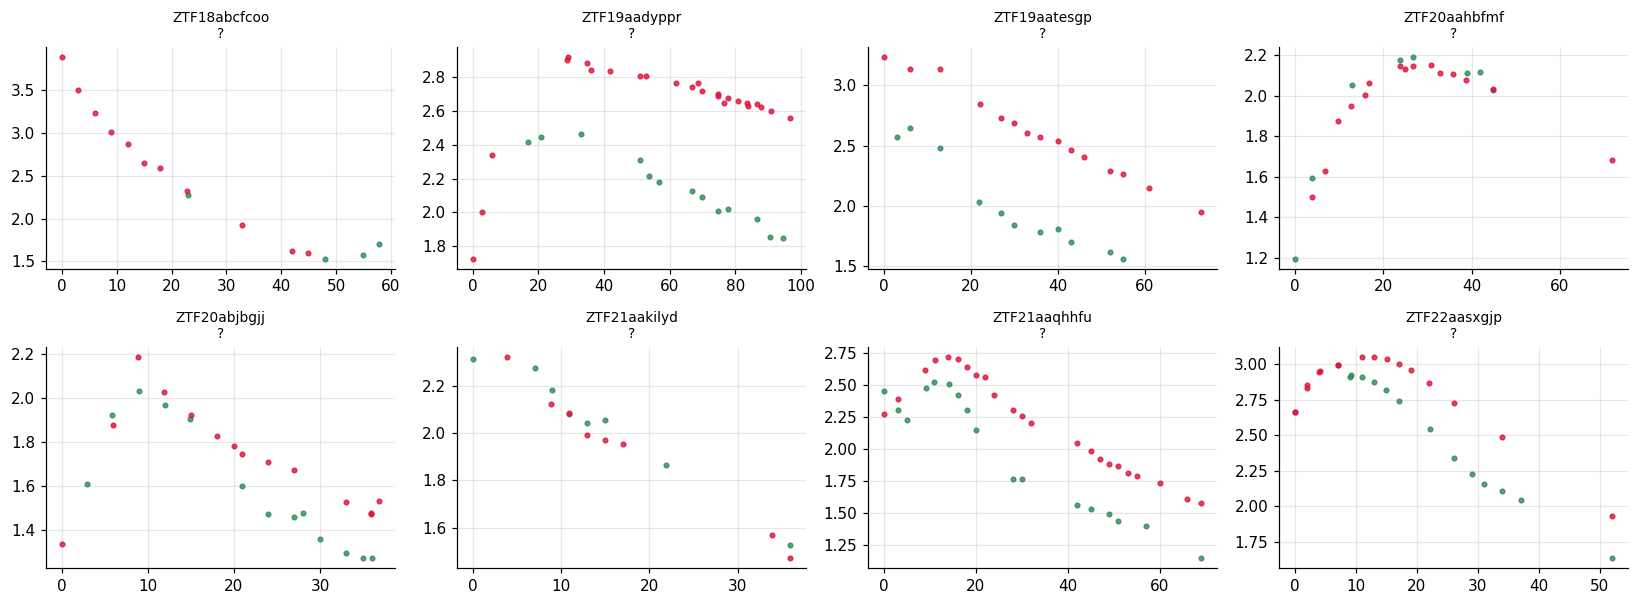

In [11]:
import json, glob
meta = json.load(open("rare_transients/meta.json"))
files = sorted(glob.glob("rare_transients/*.npz"))
print(f"{len(files)} intruders:")
for f in files:
    oid = f.split("/")[-1].replace(".npz", "")
    print(f"  {oid:15s} {meta.get(oid, {}).get('type', '?')}")

fig, axes = plt.subplots(2, 4, figsize=(15, 5.6))
for ax, f in zip(axes.ravel(), files):
    oid = f.split("/")[-1].replace(".npz", "")
    bands = D.reconstruct_bands(D.load_events(f))
    for name, colr in [("g", "seagreen"), ("r", "crimson")]:
        if name in bands:
            ax.plot(bands[name].t, bands[name].logflux, "o", ms=3,
                    color=colr, alpha=0.8)
    ax.set_title(f"{oid}\n{meta.get(oid, {}).get('type', '?')}", fontsize=9)
plt.tight_layout(); plt.show()

### Your tasks (hackathon)

1. **Score the intruders.** Extract their features
   (`clf5.features_from_files(files)`), build a `query_data` dict as in
   section 4, and push them through both the blind consensus and the
   supervised combiner. At what percentile of the pool does each intruder
   land?
2. **Which ones hide, and why?** For any intruder that does *not* stand out,
   look at its light curve and its nearest neighbours in feature space. What
   is it mimicking?
3. **Improve the detector.** Anything is allowed except touching the pool
   labels: drop or add scorers, change the combiner, engineer a feature aimed
   at the class that hides. Report AUC on the hidden-TDE pool *and* the
   intruder percentiles — did your change help both, or did you trade one for
   the other?
4. **(Open question)** Score the intruders with a *different* few-shot label
   budget: what happens with 3 labelled TDEs instead of 9? With 20? Plot
   AUC vs number of labels — the value-of-labels curve of active learning.

Honest nulls are welcome. A clean "this scorer does not help, here is the
comparison" is a real result.